IMPORT LIBRARIES

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import numpy as np

<h1>EDA<h1>

In [58]:
path = "online_gaming_behavior_dataset.csv"
df = pd.read_csv(path)
df['Location'] = df['Location'].replace({'USA': 'America'}) 
df.head(10)

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,America,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,America,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,America,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
5,9005,37,Male,Europe,RPG,20.561855,0,Easy,2,81,74,22,Low
6,9006,25,Male,America,Action,9.752716,0,Hard,1,50,13,2,Low
7,9007,25,Female,Asia,RPG,4.401729,0,Medium,10,48,27,23,Medium
8,9008,38,Female,Europe,Simulation,18.152733,0,Easy,5,101,23,41,Medium
9,9009,38,Female,Other,Sports,23.942772,0,Easy,13,95,99,36,High


In [4]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [5]:
df.info()
df['EngagementLevel'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64

<h1>Visualization<h1>

C:\Users\rigel\AppData\Local\Temp\ipykernel_42848\1764430805.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='EngagementLevel', data=df, order=order, palette='viridis')


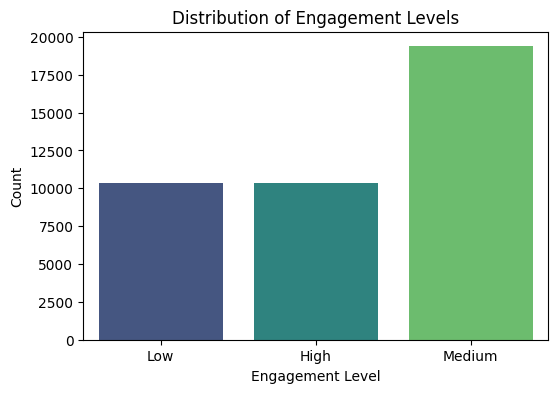

In [6]:
# Visualizzo la distribuzione di Engagement Levels
order = df['EngagementLevel'].value_counts().sort_values().index
plt.figure(figsize=(6,4))
sns.countplot(x='EngagementLevel', data=df, order=order, palette='viridis')
plt.title('Distribution of Engagement Levels')
plt.xlabel('Engagement Level')
plt.ylabel('Count')
plt.show()


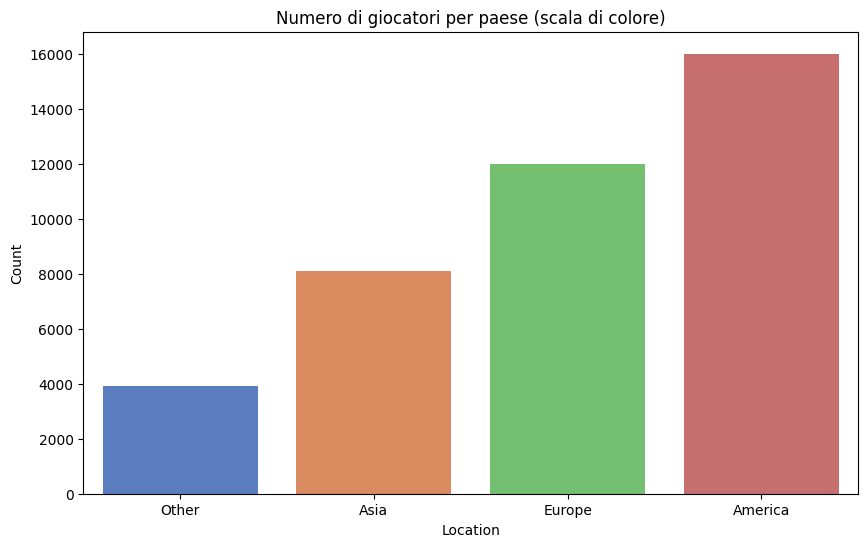

In [7]:
location = df["Location"].value_counts().reset_index()
location.columns = ['Location', 'Count']

order = df['Location'].value_counts().sort_values().index

plt.figure(figsize=(10,6))
sns.barplot(data=location, x='Location', y='Count', hue='Count', palette="muted", dodge=False, legend=False ,order=order)

plt.title("Numero di giocatori per paese (scala di colore)")
plt.show()


Text(0.5, 1.02, 'Game Genre vs Engagement Level by Gender')

<Figure size 1000x600 with 0 Axes>

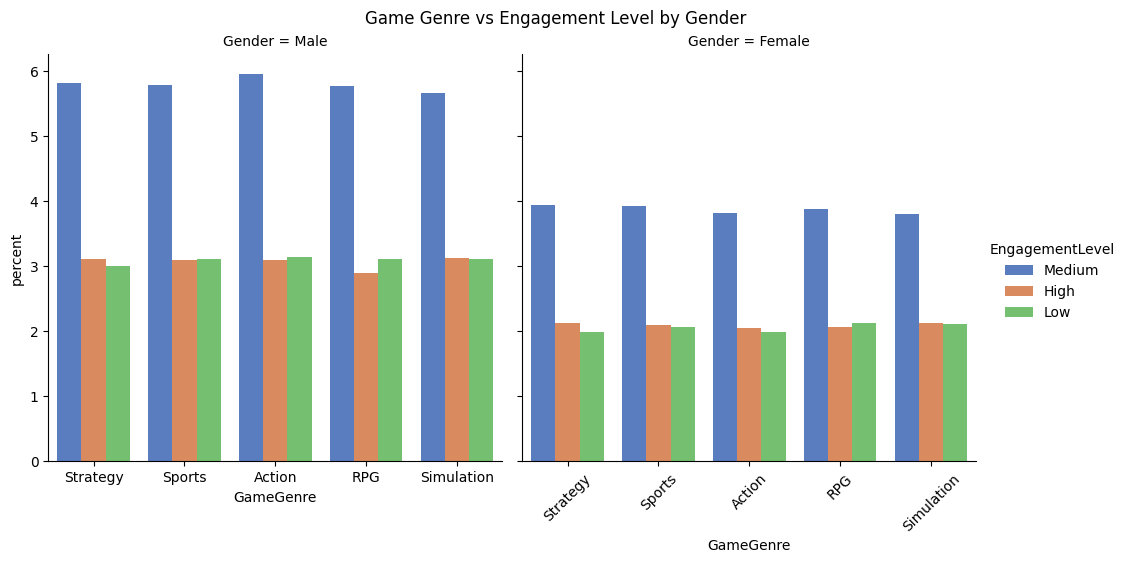

In [8]:
# Separate out Medium engagement players
medium_players = df[df['EngagementLevel'] == 'Medium']

# Compare against Low and High engagement
low_players = df[df['EngagementLevel'] == 'Low']
high_players = df[df['EngagementLevel'] == 'High']

order = df['EngagementLevel'].value_counts().sort_values().index

# Game Genre vs Engagement Level
plt.figure(figsize=(10,6))
g=sns.catplot(data=df, x='GameGenre', hue='EngagementLevel', col="Gender",kind='count', palette='muted',stat="percent")
plt.xticks(rotation=45)
g.fig.suptitle('Game Genre vs Engagement Level by Gender', y=1.02)
    

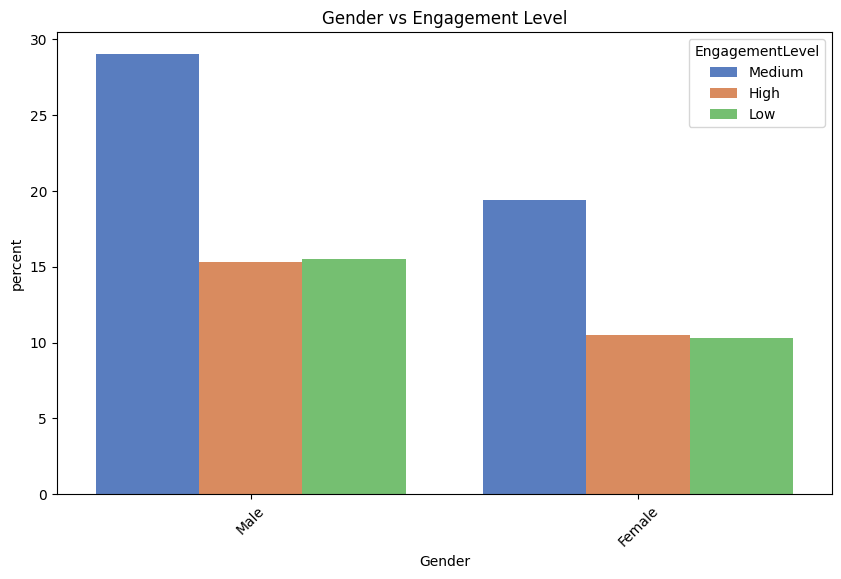

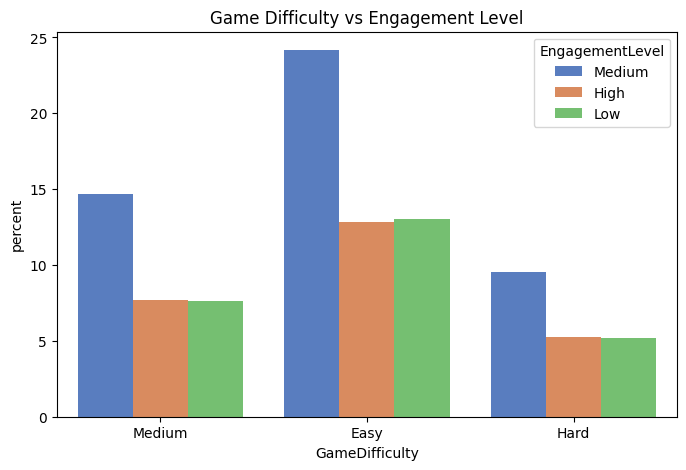

In [9]:
# Gender vs Engagement Level

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', hue='EngagementLevel', palette='muted',stat="percent")
plt.title('Gender vs Engagement Level')
plt.xticks(rotation=45)
plt.show()

# Game Difficulty vs Engagement Level
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GameDifficulty', hue='EngagementLevel', palette='muted',stat="percent")
plt.title('Game Difficulty vs Engagement Level')
plt.show()

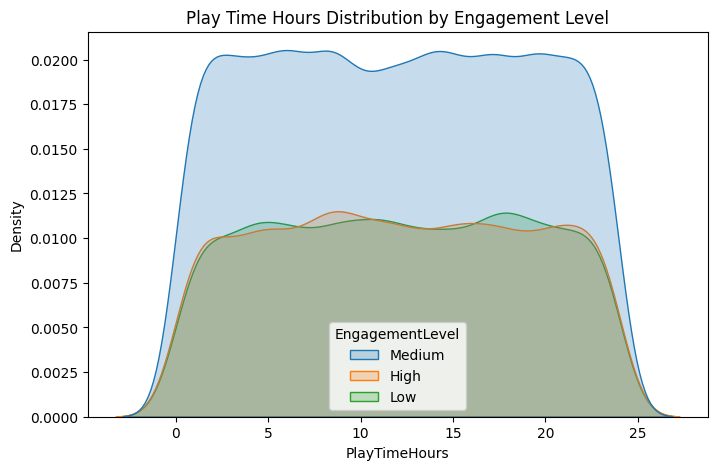

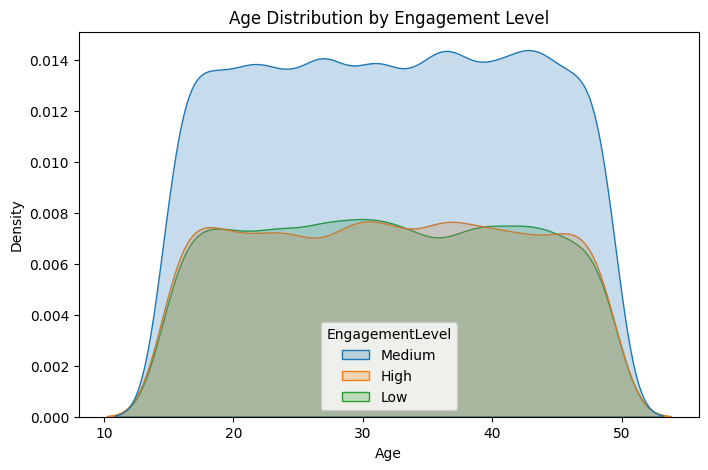

In [10]:
# Play Time Hours Distribution by Engagement Level
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='PlayTimeHours', hue='EngagementLevel', fill=True)
plt.title('Play Time Hours Distribution by Engagement Level')
# plt.xlim(0, 100)  # limit for better focus
plt.show()

# Age Distribution by Engagement Level
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Age', hue='EngagementLevel', fill=True)
plt.title('Age Distribution by Engagement Level')
plt.show()

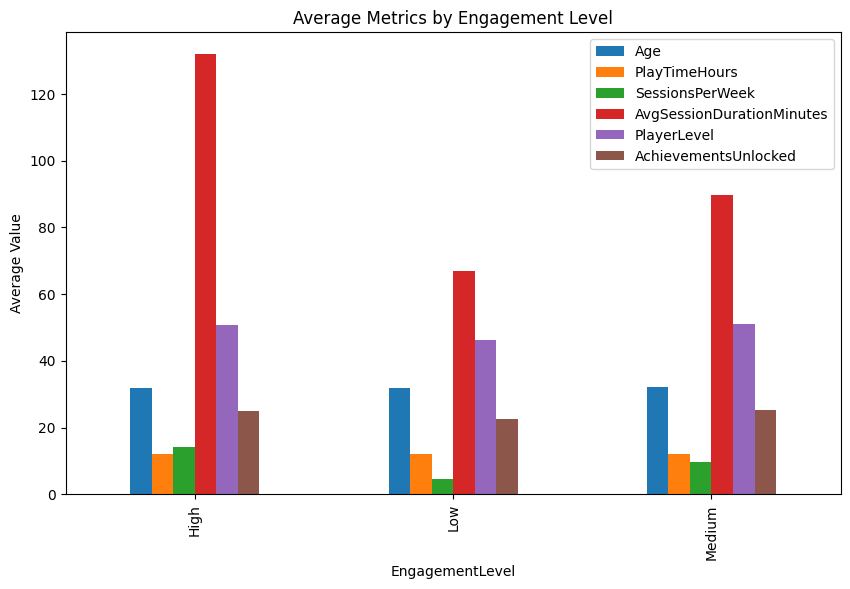

In [11]:
num_cols = ['Age', 'PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']
df.groupby('EngagementLevel')[num_cols].mean().plot(kind='bar', figsize=(10, 6), title='Average Metrics by Engagement Level')
plt.ylabel('Average Value')
plt.show()

In [28]:
#copio dataframe e seleziono le colonne da convertire
df_new = df.copy()
df_drop_playerID = df.drop(columns='PlayerID', inplace=False)
obj_cols = df_new.select_dtypes(include=['object']).columns

encoder = LabelEncoder()

for col in obj_cols:
    df_drop_playerID[col] = encoder.fit_transform(df_drop_playerID[col])

df_drop_playerID.head()
 
# encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# data_to_encode = df_drop_playerID[obj_cols]
# encoded_data = encoder.fit_transform(data_to_encode)

# encoded_df = pd.DataFrame(
#     encoded_data, 
#     columns=encoder.get_feature_names_out(obj_cols),
#     index=df_drop_playerID.index
# )

# df_final = pd.concat([df_drop_playerID.drop(columns=obj_cols), encoded_df], axis=1)

# df_final.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,1,3,4,16.271119,0,2,6,108,79,25,2
1,29,0,0,4,5.525961,0,2,5,144,11,10,2
2,22,0,0,3,8.223755,0,0,16,142,35,41,0
3,35,1,0,0,5.265351,1,0,9,85,57,47,2
4,33,1,2,0,15.531945,0,2,2,131,95,37,2


In [29]:
df_raw = df_drop_playerID.copy()

<h1 >feature engineering<h1>

Playtime settimanale e per sessione
Cosa sono: sono combinazioni di “quante volte si gioca” e “quanto dura ogni sessione”. L’idea è condensare frequenza e durata in indicatori più informativi del semplice valore singolo.

Interazioni: InGamePurchases × GameGenre
Cosa è: una feature d’interazione tra acquisti in-game (0/1) e il genere di gioco. L’idea è che l’effetto dell’acquisto sull’ingaggio dipenda dal genere: in alcuni generi comprare è associato a progressione/ritenzione maggiore, in altri lo è meno o in modo diverso.

Durata media in ore: è una semplice conversione da minuti in ore per aiutare la legibilità

Progressione: ratio AchievementsUnlocked per livello
Cosa è: misura l’“efficienza” con cui si sbloccano achievement rispetto al livello attuale. Formula: AchievementsUnlocked / (PlayerLevel + 1). Si aggiunge 1 per evitare divisioni per zero a livello 0.


In [30]:
df_raw = df_drop_playerID.copy()
# ore settimanali stimate
df_raw['WeeklyTime'] = df_raw['SessionsPerWeek']*df_raw['PlayTimeHours']

#iterazioni di Acquisto
df_raw['MonetizationByGenre'] = df_raw['InGamePurchases']*df_raw['GameGenre']

#Progressione: ratio AchievementsUnlocked per livello
df_raw["AchievementsUnlockedByLevel"] = df_raw["AchievementsUnlocked"] / (df_raw["PlayerLevel"] + 1)

df_raw["PlayerGnre"] = df_raw["PlayerLevel"] * df_raw["GameGenre"]


df_raw['PurchasesPerHour'] = df_raw['InGamePurchases'] / (df_raw['PlayTimeHours']+1)

df_raw['SessionsPerDay'] = df_raw['SessionsPerWeek'] / 7

df_raw['WeeklyInGamePurchases'] = df_raw['InGamePurchases'] / (df_raw['WeeklyTime']+1)


df_raw['LogPlayTime'] = np.log1p(df_raw['PlayTimeHours'])

df_raw['GenreLevel'] = df_raw['GameGenre'].astype(str) + '_' + df_raw['PlayerLevel'].astype(str)


df_raw['SessionsPerAge'] = df_raw['SessionsPerWeek'] / df_raw['Age']
df_raw['EngagementIntensity'] = df_raw['SessionsPerWeek'] * df_raw['AvgSessionDurationMinutes']



df_raw.head()




,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,...,MonetizationByGenre,AchievementsUnlockedByLevel,PlayerGnre,PurchasesPerHour,SessionsPerDay,WeeklyInGamePurchases,LogPlayTime,GenreLevel,SessionsPerAge,EngagementIntensity
0,43,1,3,4,16.271119,0,2,6,108,79,...,0,0.312500,316,0.000000,0.857143,0.000000,2.849036,4_79,0.139535,648
1,29,0,0,4,5.525961,0,2,5,144,11,...,0,0.833333,44,0.000000,0.714286,0.000000,1.875788,4_11,0.172414,720
2,22,0,0,3,8.223755,0,0,16,142,35,...,0,1.138889,105,0.000000,2.285714,0.000000,2.221782,3_35,0.727273,2272
3,35,1,0,0,5.265351,1,0,9,85,57,...,0,0.810345,0,0.159608,1.285714,0.020666,1.835035,0_57,0.257143,765
4,33,1,2,0,15.531945,0,2,2,131,95,...,0,0.385417,0,0.000000,0.285714,0.000000,2.805295,0_95,0.060606,262


<h1>Cleaning<h1>

In [ ]:
df_raw.drop(['WeeklylayTime'],axis=1)

In [35]:
df_clean = df_raw.drop(['PlayTimeHours','GenreLevel','PlayerGnre','InGamePurchases','WeeklyTime'],axis=1)

<Axes: >

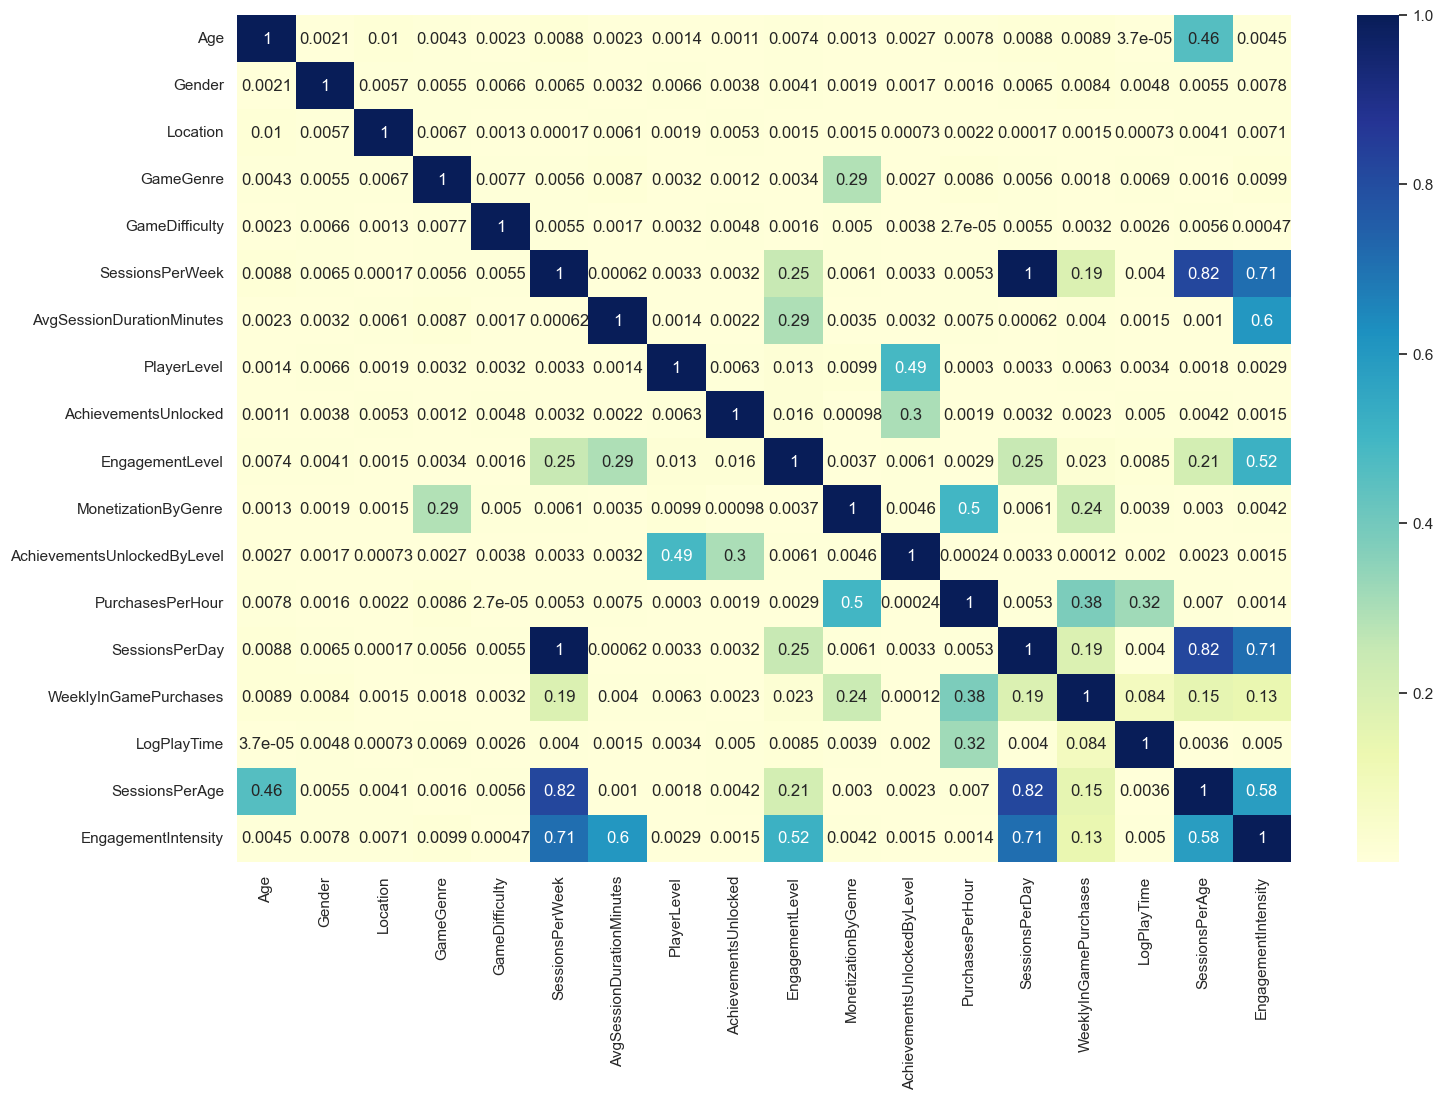

In [59]:
sns.set_theme(rc={'figure.figsize': (17, 11)})
corr = df_clean.corr()
corr_abs_int = np.abs(corr)
sns.heatmap(corr_abs_int, annot=True, cmap="YlGnBu")

<h1 style="font-size:2.2em; color:#2F5496; font-weight:700; margin-bottom:0.4em;">🔍 Analisi delle correlazioni principali</h1>

<hr style="border:1px solid #ddd; margin-top:1em; margin-bottom:1.5em;">

<div style="margin-bottom:1.2em;">
  <h2 style="color:#1E4D2B; font-size:1.4em; font-weight:700;">1️⃣ SessionsPerWeek ↔ SessionsPerAge <span style="color:#666;">(r ≈ 0.82)</span></h2>
  <ul style="list-style-type:'➤ '; margin-left:1em;">
    <li><strong>Alta correlazione positiva:</strong> gli utenti più attivi (più sessioni settimanali) tendono anche ad avere un numero di sessioni totali per età più alto.</li>
    <li>Indica una costanza nel comportamento di gioco, indipendente dal tempo.</li>
  </ul>
</div>

<div style="margin-bottom:1.2em;">
  <h2 style="color:#1E4D2B; font-size:1.4em; font-weight:700;">2️⃣ AvgSessionDurationMinutes ↔ EngagementIntensity <span style="color:#666;">(r ≈ 0.60)</span></h2>
  <ul style="list-style-type:'➤ '; margin-left:1em;">
    <li><strong>Correlazione positiva:</strong> maggiore durata media delle sessioni implica anche un livello più alto di coinvolgimento.</li>
    <li>Potrebbe essere un segnale di fidelizzazione o di game design efficace.</li>
  </ul>
</div>

<div style="margin-bottom:1.2em;">
  <h2 style="color:#1E4D2B; font-size:1.4em; font-weight:700;">3️⃣ SessionsPerWeek ↔ EngagementIntensity <span style="color:#666;">(r ≈ 0.71)</span></h2>
  <ul style="list-style-type:'➤ '; margin-left:1em;">
    <li><strong>Relazione forte:</strong> utenti più coinvolti giocano più spesso.</li>
    <li>Suggerisce che l’engagement potrebbe essere previsto o stimato usando la frequenza delle sessioni.</li>
  </ul>
</div>

<div style="margin-bottom:1.2em;">
  <h2 style="color:#9C2B1C; font-size:1.4em; font-weight:700;">4️⃣ Age ↔ SessionsPerAge <span style="color:#666;">(r ≈ -0.46)</span></h2>
  <ul style="list-style-type:'➤ '; margin-left:1em;">
    <li><strong>Correlazione negativa:</strong> giocatori più anziani hanno meno sessioni complessive.</li>
    <li>Tendenza coerente con la riduzione del tempo libero o del coinvolgimento con l’età.</li>
  </ul>
</div>

<div style="margin-bottom:1.2em;">
  <h2 style="color:#9C2B1C; font-size:1.4em; font-weight:700;">5️⃣ EngagementLevel ↔ PlayerLevel <span style="color:#666;">(r ≈ -0.49)</span></h2>
  <ul style="list-style-type:'➤ '; margin-left:1em;">
    <li><strong>Correlazione inversa moderata:</strong> i giocatori con livello alto potrebbero mostrare una diminuzione del “livello di engagement” nel tempo.</li>
    <li>Potrebbe riflettere saturazione o mancanza di nuove sfide.</li>
  </ul>
</div>

<div style="margin-bottom:1.2em;">
  <h2 style="color:#1E4D2B; font-size:1.4em; font-weight:700;">6️⃣ PurchasesPerHour ↔ MonetizationByGenre <span style="color:#666;">(r ≈ 0.50)</span></h2>
  <ul style="list-style-type:'➤ '; margin-left:1em;">
    <li><strong>Correlazione positiva:</strong> i generi di gioco più monetizzabili mostrano una maggiore frequenza di acquisti per ora di gioco.</li>
    <li>Utile per strategie di pricing o microtransazioni mirate.</li>
  </ul>
</div>

<hr style="border:1px solid #ddd; margin-top:1.5em;">





In [ ]:
df_raw.drop(['InGamePurchases','WeeklyTime'],axis=1)

,Age,Gender,Location,GameGenre,PlayTimeHours,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,...,MonetizationByGenre,AchievementsUnlockedByLevel,PlayerGnre,PurchasesPerHour,SessionsPerDay,WeeklyInGamePurchases,LogPlayTime,GenreLevel,SessionsPerAge,EngagementIntensity
0,43,1,2,4,16.271119,2,6,108,79,25,...,0,0.312500,316,0.000000,0.857143,0.000000,2.849036,4_79,0.139535,648
1,29,0,3,4,5.525961,2,5,144,11,10,...,0,0.833333,44,0.000000,0.714286,0.000000,1.875788,4_11,0.172414,720
2,22,0,3,3,8.223755,0,16,142,35,41,...,0,1.138889,105,0.000000,2.285714,0.000000,2.221782,3_35,0.727273,2272
3,35,1,3,0,5.265351,0,9,85,57,47,...,0,0.810345,0,0.159608,1.285714,0.020666,1.835035,0_57,0.257143,765
4,33,1,1,0,15.531945,2,2,131,95,37,...,0,0.385417,0,0.000000,0.285714,0.000000,2.805295,0_95,0.060606,262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,32,1,3,4,20.619662,0,4,75,85,14,...,0,0.162791,340,0.000000,0.571429,0.000000,3.073603,4_85,0.125000,300
40030,44,0,2,2,13.539280,1,19,114,71,27,...,0,0.375000,142,0.000000,2.714286,0.000000,2.676854,2_71,0.431818,2166
40031,15,0,3,1,0.240057,0,10,176,29,1,...,1,0.033333,29,0.806415,1.428571,0.294068,0.215157,1_29,0.666667,1760
40032,34,1,3,3,14.017818,2,3,128,70,10,...,3,0.140845,210,0.066588,0.428571,0.023227,2.709237,3_70,0.088235,384


In [ ]:
df_new = df.copy()
df_drop_playerID = df.drop(columns='PlayerID', inplace=False)
obj_cols = df_new.select_dtypes(include=['object']).columns
 
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
data_to_encode = df_drop_playerID[obj_cols]
encoded_data = encoder.fit_transform(data_to_encode)

encoded_df = pd.DataFrame(
    encoded_data, 
    columns=encoder.get_feature_names_out(obj_cols),
    index=df_drop_playerID.index
)

df_final = pd.concat([df_drop_playerID.drop(columns=obj_cols), encoded_df], axis=1)

df_final.head()

# TODO FORZARE A VALORI INTERI 
# TODO RINOMINARE COLONNE (USA)
# TODO COMMENTARE FEATURE CON ALTA CORRELAZIONE

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,Gender_Female,Gender_Male,Location_America,...,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,GameDifficulty_Easy,GameDifficulty_Hard,GameDifficulty_Medium,EngagementLevel_High,EngagementLevel_Low,EngagementLevel_Medium
0,43,16.271119,0,6,108,79,25,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,29,5.525961,0,5,144,11,10,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,22,8.223755,0,16,142,35,41,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,35,5.265351,1,9,85,57,47,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,33,15.531945,0,2,131,95,37,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## MODELLO

In [41]:
df_final['EngagementLevel'] = df_final[['EngagementLevel_High', 'EngagementLevel_Medium', 'EngagementLevel_Low']].idxmax(axis=1)
df_final['EngagementLevel'] = df_final['EngagementLevel'].str.replace('EngagementLevel_', '')
df_final = df_final.drop(columns=['EngagementLevel_High', 'EngagementLevel_Medium', 'EngagementLevel_Low'])



In [ ]:
df_final.head()

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,Gender_Female,Gender_Male,Location_America,...,Location_Other,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,GameDifficulty_Easy,GameDifficulty_Hard,GameDifficulty_Medium,EngagementLevel
0,43,16.271119,0,6,108,79,25,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,Medium
1,29,5.525961,0,5,144,11,10,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,Medium
2,22,8.223755,0,16,142,35,41,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,High
3,35,5.265351,1,9,85,57,47,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Medium
4,33,15.531945,0,2,131,95,37,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Medium


In [42]:
X = df_final.drop(columns=['EngagementLevel'])
y = df_final['EngagementLevel']


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(
    multi_class='multinomial',   # softmax
    solver='lbfgs',              # ottimizzatore adatto
    max_iter=1000,
    class_weight='balanced',     # utile se le classi non sono bilanciate
    random_state=42
)

log_model.fit(X_train_scaled, y_train)


c:\Users\rigel\OneDrive\Desktop\develhope\Data-PT-9-TeamProject-1-team-2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [46]:
y_pred = log_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        High       0.79      0.90      0.84      2067
         Low       0.68      0.81      0.74      2065
      Medium       0.87      0.71      0.78      3875

    accuracy                           0.79      8007
   macro avg       0.78      0.81      0.79      8007
weighted avg       0.80      0.79      0.79      8007



In [47]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7860621955788685

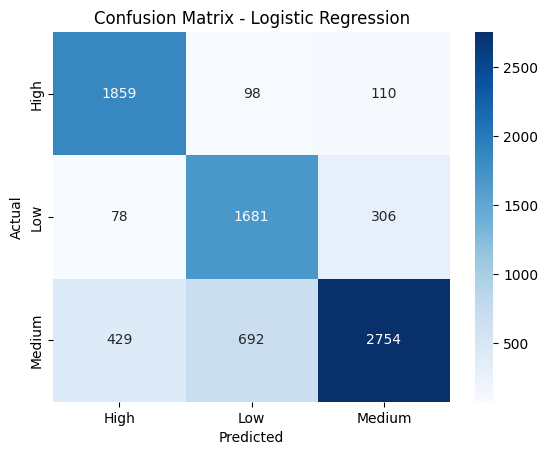

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=log_model.classes_)
sns.heatmap(pd.DataFrame(cm, index=log_model.classes_, columns=log_model.classes_), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


In [48]:
print(y_pred[:10])
print(y_test[:10].values)


['Medium' 'Low' 'High' 'Medium' 'Low' 'Low' 'Low' 'High' 'Low' 'Medium']
['High' 'High' 'High' 'Medium' 'Medium' 'Low' 'Low' 'High' 'Medium' 'Low']


In [ ]:
y_pred_proba = log_model.predict_proba(X_test_scaled)
print(y_pred_proba[:5])


[[2.60784310e-02 3.66524710e-01 6.07396859e-01]
 [2.14622224e-04 8.83370620e-01 1.16414758e-01]
 [9.02149306e-01 7.01645894e-04 9.71490477e-02]
 [2.51715944e-01 6.12070687e-02 6.87076988e-01]
 [4.00566925e-03 7.14413243e-01 2.81581088e-01]]


In [ ]:
log_model.classes_


array(['High', 'Low', 'Medium'], dtype=object)

In [53]:
# Usa le colonne originali del training
columns_originali = X.columns

# Crea il dizionario con i tuoi valori noti
dati_nuovo = {
    'Age': 48,
    'PlayTimeHours': 32.5,
    'InGamePurchases': 3,
    'SessionsPerWeek': 38,
    'AvgSessionDurationMinutes': 25,
    'PlayerLevel': 72,
    'AchievementsUnlocked': 40,
    'Gender_Female': 1.0,
    'Gender_Male': 0.0,
    'Location_America': 1.0,
    'Location_Asia': 0.0,
    'Location_Europe': 0.0,
    'Location_Other': 0.0,
    'GameGenre_Action': 1.0,
    'GameGenre_RPG': 0.0,
    'GameGenre_Simulation': 0.0,
    'GameGenre_Sports': 0.0,
    'GameGenre_Strategy': 0.0,
    'GameDifficulty_Easy': 0.0,
    'GameDifficulty_Medium': 1.0,
    'GameDifficulty_Hard': 0.0
}

# Crea un DataFrame con tutte le colonne del modello
nuovo_giocatore = pd.DataFrame([{col: dati_nuovo.get(col, 0) for col in columns_originali}])

# Scala e predici
nuovo_giocatore_scaled = scaler.transform(nuovo_giocatore)
pred = log_model.predict(nuovo_giocatore_scaled)
prob = log_model.predict_proba(nuovo_giocatore_scaled)

print("🎯 Predizione:", pred[0])
print("📊 Probabilità per classe:", dict(zip(log_model.classes_, prob[0])))


🎯 Predizione: High
📊 Probabilità per classe: {'High': np.float64(0.9974975484859857), 'Low': np.float64(4.820656050936414e-07), 'Medium': np.float64(0.0025019694484092136)}


In [54]:
nuovo_giocatore = pd.DataFrame([{col: dati_nuovo.get(col, 0) for col in columns_originali}])
nuovo_giocatore

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,Gender_Female,Gender_Male,Location_America,...,Location_Europe,Location_Other,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,GameDifficulty_Easy,GameDifficulty_Hard,GameDifficulty_Medium
0,48,32.5,3,38,25,72,40,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
